**Development record:** This is the historical Checkpoint 2 notebook. The corrected model, final definitions and reproducible results are in `final_analysis.ipynb`.

# Urban Delivery Network Model

This notebook creates the first version of our urban delivery network. It calculates normal delivery routes and tests how road closures and congestion affect the routes.

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import random
from collections import Counter

In [3]:
random.seed(42)

road_network = nx.grid_2d_graph(6, 6)

for road in road_network.edges:
    road_network.edges[road]["distance"] = random.randint(1, 5)

print("Number of locations:", road_network.number_of_nodes())
print("Number of roads:", road_network.number_of_edges())
print("Connected network:", nx.is_connected(road_network))

Number of locations: 36
Number of roads: 60
Connected network: True


In [4]:
restaurants = [(0, 0), (5, 5), (0, 5)]

customers = [
    (1, 1),
    (1, 4),
    (2, 2),
    (2, 5),
    (3, 0),
    (3, 3),
    (4, 1),
    (4, 4),
    (5, 2),
    (5, 4)
]

print("Restaurants:", restaurants)
print("Number of customers:", len(customers))

Restaurants: [(0, 0), (5, 5), (0, 5)]
Number of customers: 10


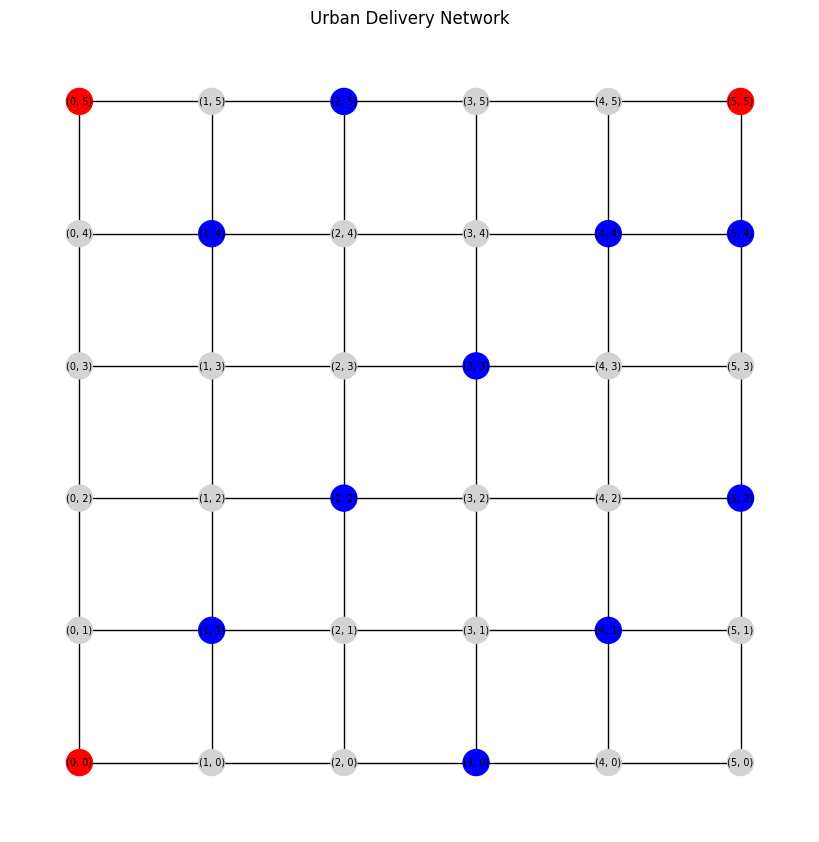

In [5]:
node_colours = []

for node in road_network.nodes:
    if node in restaurants:
        node_colours.append("red")
    elif node in customers:
        node_colours.append("blue")
    else:
        node_colours.append("lightgray")

plt.figure(figsize=(8, 8))

nx.draw(
    road_network,
    pos={node: node for node in road_network.nodes},
    node_color=node_colours,
    node_size=350,
    with_labels=True,
    font_size=7
)

plt.title("Urban Delivery Network")
plt.show()

## Baseline Restaurant Assignment

Each customer is assigned to the restaurant with the lowest weighted distance. These assignments will remain fixed during the road closure experiments.

In [6]:
customer_restaurants = {}
baseline_routes = {}
baseline_distances = {}

for customer in customers:
    restaurant_distances = {}

    for restaurant in restaurants:
        distance = nx.shortest_path_length(
            road_network,
            restaurant,
            customer,
            weight="distance"
        )

        restaurant_distances[restaurant] = distance

    nearest_restaurant = min(
        restaurant_distances,
        key=restaurant_distances.get
    )

    customer_restaurants[customer] = nearest_restaurant
    baseline_distances[customer] = restaurant_distances[nearest_restaurant]

    baseline_routes[customer] = nx.shortest_path(
        road_network,
        nearest_restaurant,
        customer,
        weight="distance"
    )

for customer in customers:
    print(
        "Customer:", customer,
        "| Restaurant:", customer_restaurants[customer],
        "| Distance:", baseline_distances[customer],
        "| Route:", baseline_routes[customer]
    )

Customer: (1, 1) | Restaurant: (0, 0) | Distance: 2 | Route: [(0, 0), (1, 0), (1, 1)]
Customer: (1, 4) | Restaurant: (0, 5) | Distance: 6 | Route: [(0, 5), (0, 4), (1, 4)]
Customer: (2, 2) | Restaurant: (0, 0) | Distance: 6 | Route: [(0, 0), (1, 0), (1, 1), (1, 2), (2, 2)]
Customer: (2, 5) | Restaurant: (5, 5) | Distance: 5 | Route: [(5, 5), (4, 5), (3, 5), (2, 5)]
Customer: (3, 0) | Restaurant: (0, 0) | Distance: 6 | Route: [(0, 0), (1, 0), (2, 0), (3, 0)]
Customer: (3, 3) | Restaurant: (0, 0) | Distance: 9 | Route: [(0, 0), (1, 0), (1, 1), (2, 1), (3, 1), (3, 2), (3, 3)]
Customer: (4, 1) | Restaurant: (0, 0) | Distance: 8 | Route: [(0, 0), (1, 0), (1, 1), (2, 1), (3, 1), (4, 1)]
Customer: (4, 4) | Restaurant: (5, 5) | Distance: 4 | Route: [(5, 5), (5, 4), (4, 4)]
Customer: (5, 2) | Restaurant: (5, 5) | Distance: 6 | Route: [(5, 5), (5, 4), (5, 3), (5, 2)]
Customer: (5, 4) | Restaurant: (5, 5) | Distance: 1 | Route: [(5, 5), (5, 4)]


## Baseline Results and Road Usage

The baseline average distance represents normal delivery conditions before any roads are closed. Road usage is calculated by counting how many baseline delivery routes contain each road.

In [7]:
total_baseline_distance = sum(baseline_distances.values())

average_baseline_distance = (
    total_baseline_distance / len(baseline_distances)
)

print("Baseline average delivery distance:", average_baseline_distance)

Baseline average delivery distance: 5.3


In [8]:
road_usage = Counter()

for route in baseline_routes.values():
    for position in range(len(route) - 1):
        first_node = route[position]
        second_node = route[position + 1]

        road = tuple(sorted([first_node, second_node]))
        road_usage[road] += 1

print("Road usage ranking:")

for road, usage_count in road_usage.most_common():
    print(road, "used by", usage_count, "deliveries")

Road usage ranking:
((0, 0), (1, 0)) used by 5 deliveries
((1, 0), (1, 1)) used by 4 deliveries
((5, 4), (5, 5)) used by 3 deliveries
((1, 1), (2, 1)) used by 2 deliveries
((2, 1), (3, 1)) used by 2 deliveries
((0, 4), (0, 5)) used by 1 deliveries
((0, 4), (1, 4)) used by 1 deliveries
((1, 1), (1, 2)) used by 1 deliveries
((1, 2), (2, 2)) used by 1 deliveries
((4, 5), (5, 5)) used by 1 deliveries
((3, 5), (4, 5)) used by 1 deliveries
((2, 5), (3, 5)) used by 1 deliveries
((1, 0), (2, 0)) used by 1 deliveries
((2, 0), (3, 0)) used by 1 deliveries
((3, 1), (3, 2)) used by 1 deliveries
((3, 2), (3, 3)) used by 1 deliveries
((3, 1), (4, 1)) used by 1 deliveries
((4, 4), (5, 4)) used by 1 deliveries
((5, 3), (5, 4)) used by 1 deliveries
((5, 2), (5, 3)) used by 1 deliveries


## Baseline Delivery Routes

The orange roads are used by at least one baseline delivery route. The red roads are the most frequently used roads. Red nodes represent restaurants, blue nodes represent customers and grey nodes represent intersections.

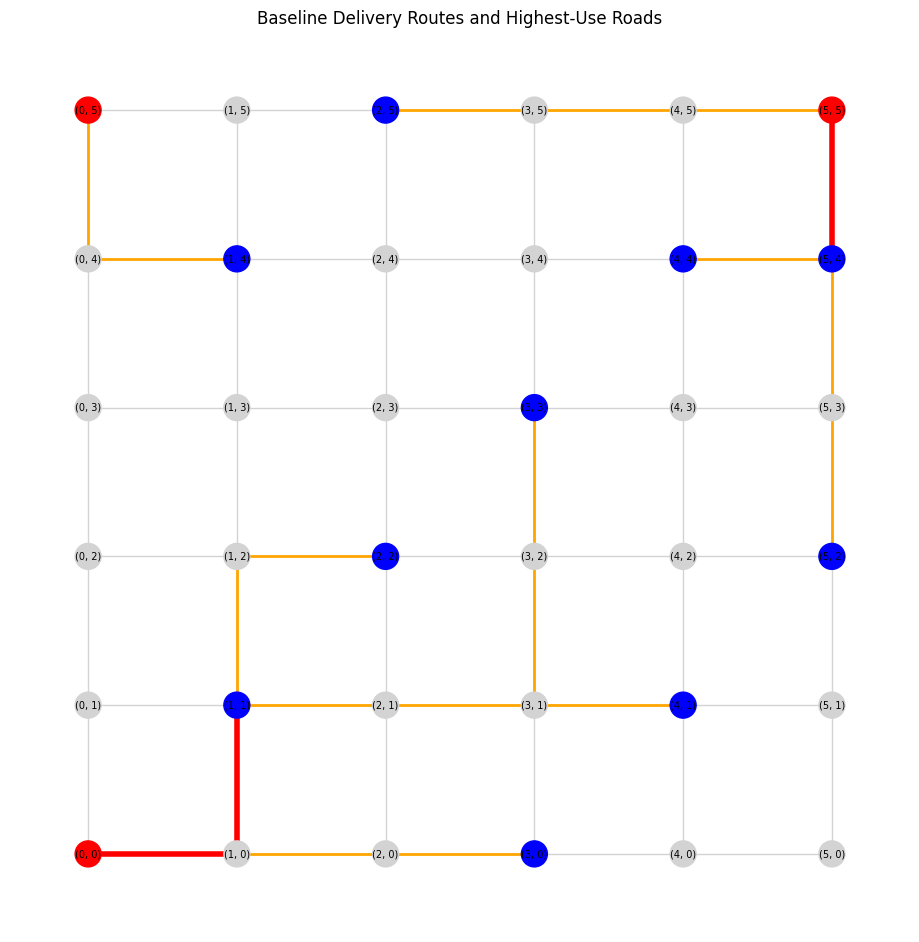

Top three highest-use roads:
((0, 0), (1, 0)) used by 5 deliveries
((1, 0), (1, 1)) used by 4 deliveries
((5, 4), (5, 5)) used by 3 deliveries


In [9]:
highest_use_roads = []

for road, usage_count in road_usage.most_common(3):
    highest_use_roads.append(road)

baseline_route_roads = set(road_usage.keys())

edge_colours = []
edge_widths = []

for first_node, second_node in road_network.edges:
    road = tuple(sorted([first_node, second_node]))

    if road in highest_use_roads:
        edge_colours.append("red")
        edge_widths.append(4)
    elif road in baseline_route_roads:
        edge_colours.append("orange")
        edge_widths.append(2)
    else:
        edge_colours.append("lightgray")
        edge_widths.append(1)

node_colours = []

for node in road_network.nodes:
    if node in restaurants:
        node_colours.append("red")
    elif node in customers:
        node_colours.append("blue")
    else:
        node_colours.append("lightgray")

positions = {node: node for node in road_network.nodes}

plt.figure(figsize=(9, 9))

nx.draw(
    road_network,
    pos=positions,
    node_color=node_colours,
    edge_color=edge_colours,
    width=edge_widths,
    node_size=350,
    with_labels=True,
    font_size=7
)

plt.title("Baseline Delivery Routes and Highest-Use Roads")
plt.show()

print("Top three highest-use roads:")

for road in highest_use_roads:
    print(road, "used by", road_usage[road], "deliveries")

## Random Road Closure

Three roads are selected randomly and removed from a copy of the original network. The same restaurant-customer assignments are used, but the delivery routes are recalculated.

In [10]:
number_of_closures = 3

random.seed(10)

random_closed_roads = random.sample(
    list(road_network.edges),
    number_of_closures
)

random_network = road_network.copy()
random_network.remove_edges_from(random_closed_roads)

random_distances = {}
random_routes = {}
unreachable_customers = []

for customer in customers:
    restaurant = customer_restaurants[customer]

    try:
        random_distances[customer] = nx.shortest_path_length(
            random_network,
            restaurant,
            customer,
            weight="distance"
        )

        random_routes[customer] = nx.shortest_path(
            random_network,
            restaurant,
            customer,
            weight="distance"
        )

    except nx.NetworkXNoPath:
        unreachable_customers.append(customer)

if len(random_distances) > 0:
    average_random_distance = (
        sum(random_distances.values()) / len(random_distances)
    )
else:
    average_random_distance = 0

reachable_percentage = (
    len(random_distances) / len(customers)
) * 100

distance_increase = (
    (average_random_distance - average_baseline_distance)
    / average_baseline_distance
) * 100

print("Randomly closed roads:", random_closed_roads)
print("Average distance after closure:", average_random_distance)
print("Distance increase:", round(distance_increase, 2), "%")
print("Customers reachable:", reachable_percentage, "%")
print("Unreachable customers:", unreachable_customers)

Randomly closed roads: [((3, 1), (3, 2)), ((0, 1), (1, 1)), ((2, 2), (2, 3))]
Average distance after closure: 5.4
Distance increase: 1.89 %
Customers reachable: 100.0 %
Unreachable customers: []


### Random Closure Network

Orange roads are used by the recalculated delivery routes. Red dashed roads are closed. Grey roads remain available but are not used by the recalculated routes.

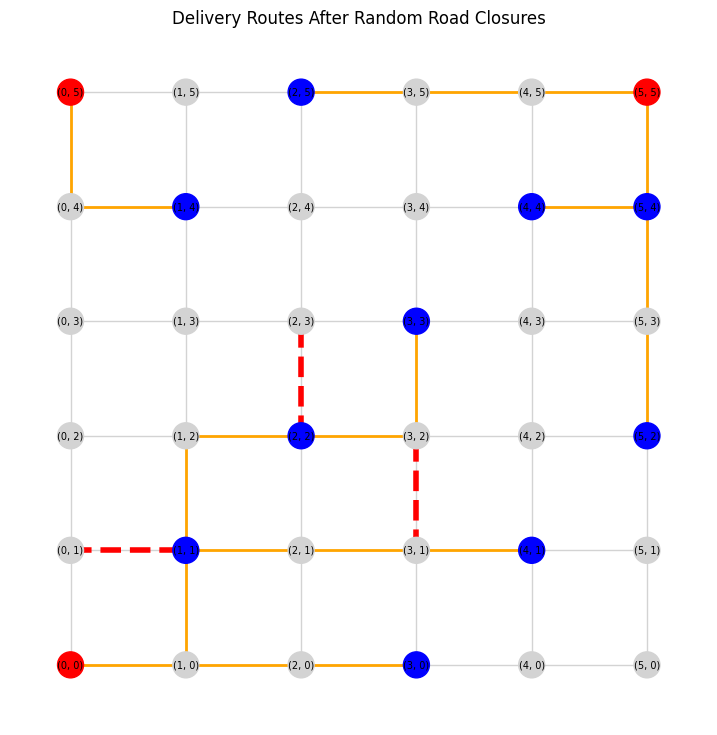

In [11]:
random_route_roads = set()

for route in random_routes.values():
    for position in range(len(route) - 1):
        road = tuple(sorted([
            route[position],
            route[position + 1]
        ]))

        random_route_roads.add(road)

closed_road_set = set()

for road in random_closed_roads:
    closed_road_set.add(tuple(sorted(road)))

available_route_roads = []

for road in random_route_roads:
    if road not in closed_road_set:
        available_route_roads.append(road)

plt.figure(figsize=(9, 9))

nx.draw_networkx_nodes(
    road_network,
    pos=positions,
    node_color=node_colours,
    node_size=350
)

nx.draw_networkx_labels(
    road_network,
    pos=positions,
    font_size=7
)

nx.draw_networkx_edges(
    road_network,
    pos=positions,
    edge_color="lightgray",
    width=1
)

nx.draw_networkx_edges(
    road_network,
    pos=positions,
    edgelist=available_route_roads,
    edge_color="orange",
    width=2
)

nx.draw_networkx_edges(
    road_network,
    pos=positions,
    edgelist=list(closed_road_set),
    edge_color="red",
    width=4,
    style="dashed"
)

plt.title("Delivery Routes After Random Road Closures")
plt.axis("off")
plt.show()

## Highest-Use Road Closure

The three roads with the highest baseline usage are removed. The restaurant-customer assignments remain unchanged, but the delivery routes are recalculated.

In [12]:
high_use_closed_roads = []

for road, usage_count in road_usage.most_common(number_of_closures):
    high_use_closed_roads.append(road)

high_use_network = road_network.copy()
high_use_network.remove_edges_from(high_use_closed_roads)

high_use_distances = {}
high_use_routes = {}
high_use_unreachable = []

for customer in customers:
    restaurant = customer_restaurants[customer]

    try:
        high_use_distances[customer] = nx.shortest_path_length(
            high_use_network,
            restaurant,
            customer,
            weight="distance"
        )

        high_use_routes[customer] = nx.shortest_path(
            high_use_network,
            restaurant,
            customer,
            weight="distance"
        )

    except nx.NetworkXNoPath:
        high_use_unreachable.append(customer)

if len(high_use_distances) > 0:
    average_high_use_distance = (
        sum(high_use_distances.values())
        / len(high_use_distances)
    )
else:
    average_high_use_distance = 0

high_use_reachable_percentage = (
    len(high_use_distances) / len(customers)
) * 100

high_use_distance_increase = (
    (average_high_use_distance - average_baseline_distance)
    / average_baseline_distance
) * 100

print("Highest-use roads closed:", high_use_closed_roads)
print("Average distance after closure:", average_high_use_distance)
print(
    "Distance increase:",
    round(high_use_distance_increase, 2),
    "%"
)
print(
    "Customers reachable:",
    high_use_reachable_percentage,
    "%"
)
print("Unreachable customers:", high_use_unreachable)

Highest-use roads closed: [((0, 0), (1, 0)), ((1, 0), (1, 1)), ((5, 4), (5, 5))]
Average distance after closure: 8.4
Distance increase: 58.49 %
Customers reachable: 100.0 %
Unreachable customers: []


### Highest-Use Road Closure Network

Orange roads are used by the recalculated delivery routes. Red dashed roads are the closed highest-use roads. Grey roads remain available but are not used by the recalculated routes.

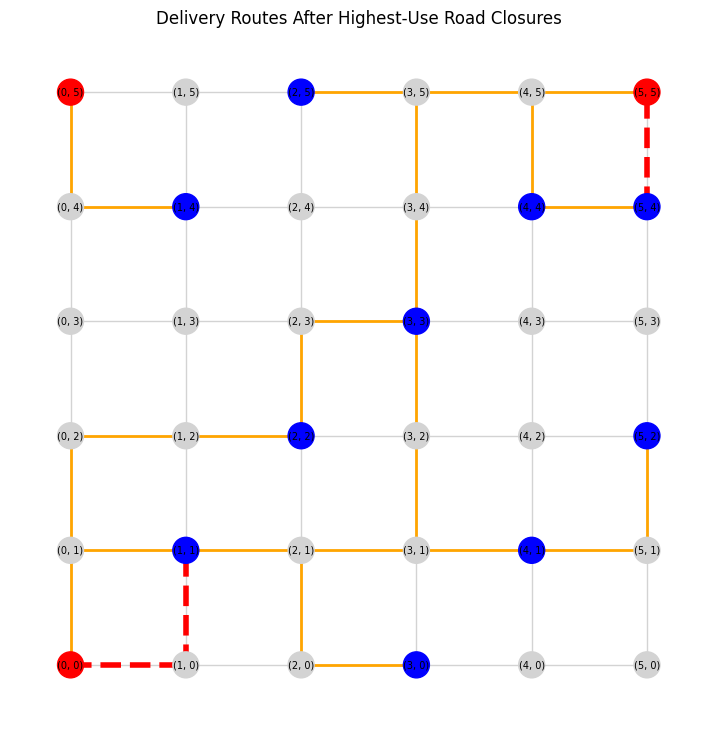

In [13]:
high_use_route_roads = set()

for route in high_use_routes.values():
    for position in range(len(route) - 1):
        road = tuple(sorted([
            route[position],
            route[position + 1]
        ]))

        high_use_route_roads.add(road)

high_use_closed_set = set(high_use_closed_roads)

available_high_use_routes = []

for road in high_use_route_roads:
    if road not in high_use_closed_set:
        available_high_use_routes.append(road)

plt.figure(figsize=(9, 9))

nx.draw_networkx_nodes(
    road_network,
    pos=positions,
    node_color=node_colours,
    node_size=350
)

nx.draw_networkx_labels(
    road_network,
    pos=positions,
    font_size=7
)

nx.draw_networkx_edges(
    road_network,
    pos=positions,
    edge_color="lightgray",
    width=1
)

nx.draw_networkx_edges(
    road_network,
    pos=positions,
    edgelist=available_high_use_routes,
    edge_color="orange",
    width=2
)

nx.draw_networkx_edges(
    road_network,
    pos=positions,
    edgelist=list(high_use_closed_set),
    edge_color="red",
    width=4,
    style="dashed"
)

plt.title("Delivery Routes After Highest-Use Road Closures")
plt.axis("off")
plt.show()

## Initial Comparison

This comparison shows the average delivery distance and customer accessibility under the baseline and two road-closure cases.

In [14]:
scenario_names = [
    "Baseline",
    "Random closure",
    "High-use closure"
]

average_distances = [
    average_baseline_distance,
    average_random_distance,
    average_high_use_distance
]

reachable_percentages = [
    100,
    reachable_percentage,
    high_use_reachable_percentage
]

print("Scenario comparison")
print()

for position in range(len(scenario_names)):
    print(
        scenario_names[position],
        "| Average distance:",
        round(average_distances[position], 2),
        "| Reachable:",
        round(reachable_percentages[position], 2),
        "%"
    )

Scenario comparison

Baseline | Average distance: 5.3 | Reachable: 100 %
Random closure | Average distance: 5.4 | Reachable: 100.0 %
High-use closure | Average distance: 8.4 | Reachable: 100.0 %


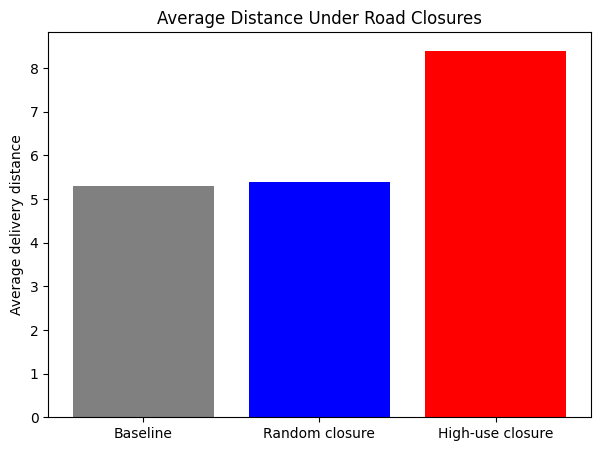

In [15]:
plt.figure(figsize=(7, 5))

plt.bar(
    scenario_names,
    average_distances,
    color=["gray", "blue", "red"]
)

plt.ylabel("Average delivery distance")
plt.title("Average Distance Under Road Closures")
plt.show()

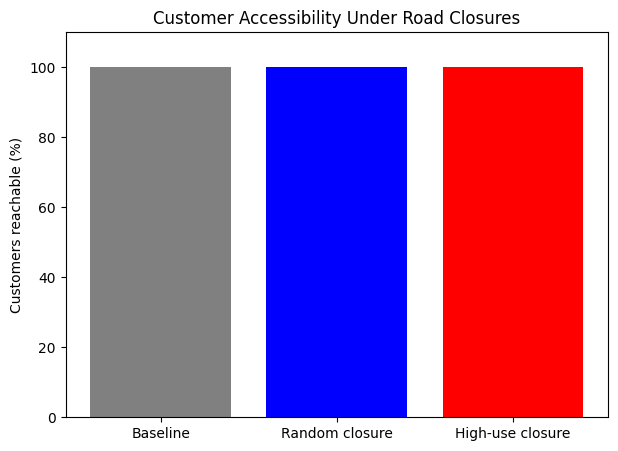

In [16]:
plt.figure(figsize=(7, 5))

plt.bar(
    scenario_names,
    reachable_percentages,
    color=["gray", "blue", "red"]
)

plt.ylabel("Customers reachable (%)")
plt.ylim(0, 110)
plt.title("Customer Accessibility Under Road Closures")
plt.show()

## Traffic Congestion Case

Congested roads remain open, but their travel cost is increased. In this initial case, the three highest-use roads receive a congestion multiplier of 2. Delivery routes are then recalculated using travel cost.

In [17]:
congestion_network = road_network.copy()

for first_node, second_node in congestion_network.edges:
    normal_distance = congestion_network.edges[
        first_node,
        second_node
    ]["distance"]

    congestion_network.edges[
        first_node,
        second_node
    ]["travel_cost"] = normal_distance

congested_roads = high_use_closed_roads.copy()
congestion_multiplier = 2

for road in congested_roads:
    normal_distance = congestion_network.edges[road]["distance"]

    congestion_network.edges[road]["travel_cost"] = (
        normal_distance * congestion_multiplier
    )

print("Congested roads:", congested_roads)
print("Congestion multiplier:", congestion_multiplier)

Congested roads: [((0, 0), (1, 0)), ((1, 0), (1, 1)), ((5, 4), (5, 5))]
Congestion multiplier: 2


In [18]:
congestion_routes = {}
congestion_costs = {}

for customer in customers:
    restaurant = customer_restaurants[customer]

    congestion_routes[customer] = nx.shortest_path(
        congestion_network,
        restaurant,
        customer,
        weight="travel_cost"
    )

    congestion_costs[customer] = nx.shortest_path_length(
        congestion_network,
        restaurant,
        customer,
        weight="travel_cost"
    )

average_congestion_cost = (
    sum(congestion_costs.values())
    / len(congestion_costs)
)

congestion_cost_increase = (
    (average_congestion_cost - average_baseline_distance)
    / average_baseline_distance
) * 100

changed_routes = 0

for customer in customers:
    if congestion_routes[customer] != baseline_routes[customer]:
        changed_routes += 1

print(
    "Average baseline travel cost:",
    round(average_baseline_distance, 2)
)

print(
    "Average travel cost under congestion:",
    round(average_congestion_cost, 2)
)

print(
    "Travel cost increase:",
    round(congestion_cost_increase, 2),
    "%"
)

print(
    "Number of delivery routes changed:",
    changed_routes
)

Average baseline travel cost: 5.3
Average travel cost under congestion: 6.3
Travel cost increase: 18.87 %
Number of delivery routes changed: 4


### Congestion Network

Purple roads are congested and have a higher travel cost. Orange roads are used by the recalculated delivery routes. Congested roads remain open.

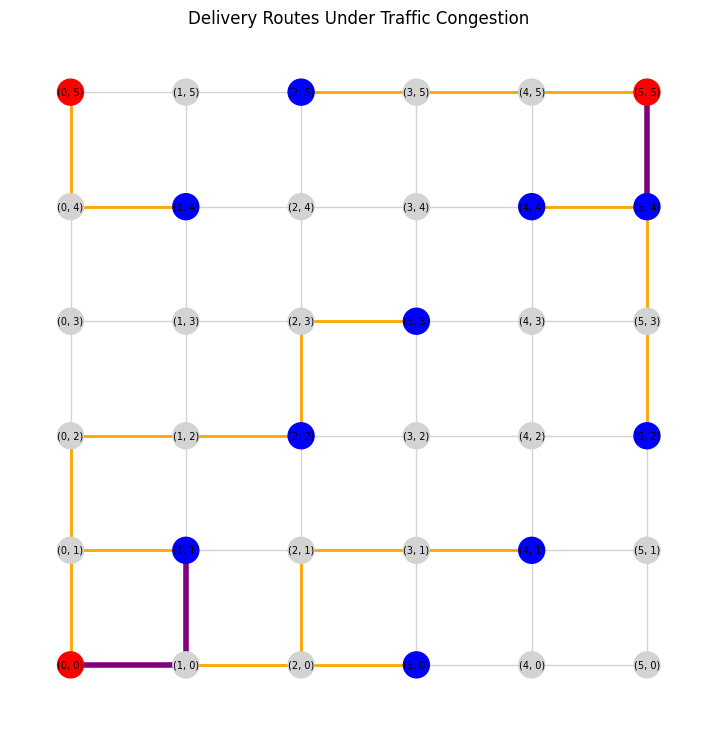

In [19]:
congestion_route_roads = set()

for route in congestion_routes.values():
    for position in range(len(route) - 1):
        road = tuple(sorted([
            route[position],
            route[position + 1]
        ]))

        congestion_route_roads.add(road)

congested_road_set = set(congested_roads)

plt.figure(figsize=(9, 9))

nx.draw_networkx_nodes(
    congestion_network,
    pos=positions,
    node_color=node_colours,
    node_size=350
)

nx.draw_networkx_labels(
    congestion_network,
    pos=positions,
    font_size=7
)

nx.draw_networkx_edges(
    congestion_network,
    pos=positions,
    edge_color="lightgray",
    width=1
)

nx.draw_networkx_edges(
    congestion_network,
    pos=positions,
    edgelist=list(congestion_route_roads),
    edge_color="orange",
    width=2
)

nx.draw_networkx_edges(
    congestion_network,
    pos=positions,
    edgelist=list(congested_road_set),
    edge_color="purple",
    width=4
)

plt.title("Delivery Routes Under Traffic Congestion")
plt.axis("off")
plt.show()

## Initial Comparison of Disruption Cases

The results below are initial results from one network and one disruption level. They demonstrate the current model and are not the final project results.

In [20]:
all_scenarios = [
    "Baseline",
    "Random closure",
    "High-use closure",
    "Congestion"
]

average_route_costs = [
    average_baseline_distance,
    average_random_distance,
    average_high_use_distance,
    average_congestion_cost
]

all_reachable_percentages = [
    100,
    reachable_percentage,
    high_use_reachable_percentage,
    100
]

for position in range(len(all_scenarios)):
    print(
        all_scenarios[position],
        "| Average route cost:",
        round(average_route_costs[position], 2),
        "| Customers reachable:",
        round(all_reachable_percentages[position], 2),
        "%"
    )

Baseline | Average route cost: 5.3 | Customers reachable: 100 %
Random closure | Average route cost: 5.4 | Customers reachable: 100.0 %
High-use closure | Average route cost: 8.4 | Customers reachable: 100.0 %
Congestion | Average route cost: 6.3 | Customers reachable: 100 %


## Current Progress

The current model can create a synthetic weighted road network, assign customers to restaurants and calculate baseline delivery routes. It can identify frequently used roads and compare random road closures with closures of the highest use roads. An initial congestion case has also been added using a travel cost multiplier.

These results are preliminary because only one network and one disruption level have been tested.

## Remaining Work

- Repeat the random closure experiment using multiple random seeds.
- Test different numbers of closed roads.
- Test different congestion multipliers.
- Calculate the average and variation across repeated experiments.
- Add more checks for unusual or extreme cases.
- Improve the comparison figures.
- Complete the final analysis and report.

### Initial Observations

In this initial experiment, the random closures caused only a small increase in average route distance. Closing the three highest-use roads caused a much larger increase. Congestion also increased the average route cost and changed four delivery routes.

All customers remained reachable in these initial cases. These results are only preliminary because they come from one network, one random closure selection and one disruption level.